<a href="https://colab.research.google.com/github/Tchalz/delete_now/blob/master/CUSTOMER_SEGMENTATION(K_MEANS)_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

In [79]:
df = pd.read_csv('/content/Mall_Customers.csv')

In [80]:
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [81]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000    

In [82]:
print(df.duplicated().sum())

0


##AGE DISTRIBUTION SEABORN

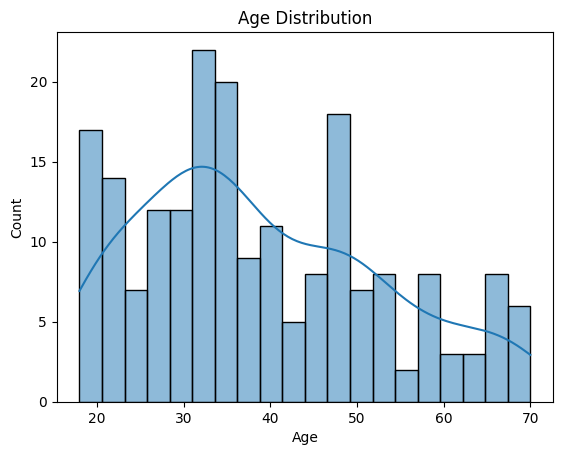

In [83]:
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

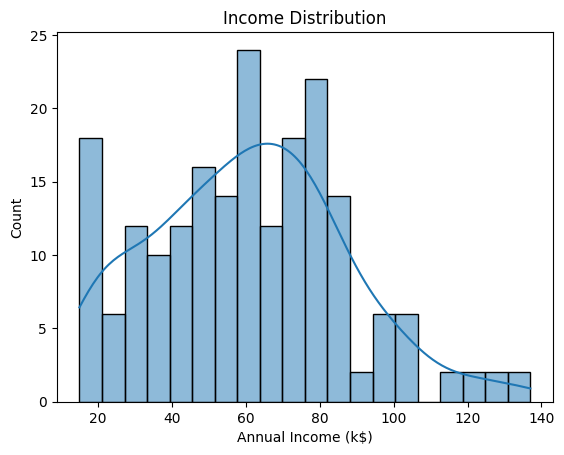

In [84]:
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title("Income Distribution")
plt.show()

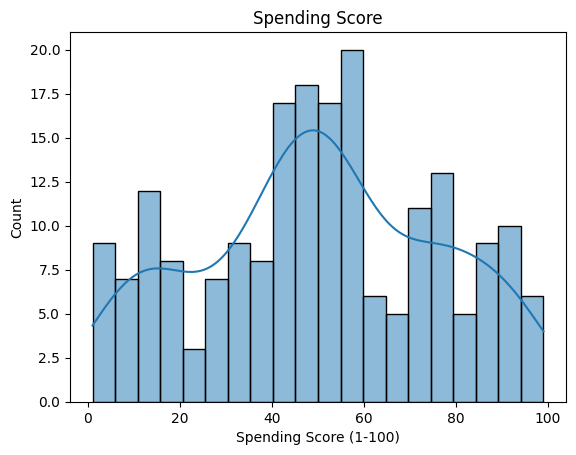

In [85]:
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title("Spending Score")
plt.show()

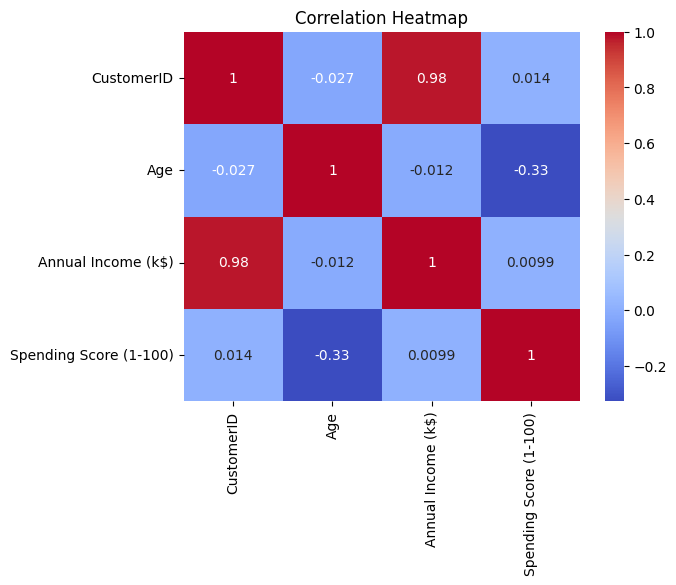

In [86]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##SELECT FEATURES FOR CLUSTERING

In [87]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

##SCALE THE DATA

In [88]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##FIND BEST K
ELBOW + SILHOUETTE + CH SCORE

In [89]:
import matplotlib.pyplot as plt

k_range = range(2, 11)
inertia_values = []
silhouette_scores = []
ch_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)

    # Calculate Inertia (Within-Cluster Sum of Squares)
    inertia_values.append(km.inertia_)

    # Calculate Silhouette Score
    labels = km.labels_
    silhouette_scores.append(silhouette_score(X_scaled, labels))

    #Calculate calinski_harabasz scores
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))


##PLOT EVALUATION METHOD

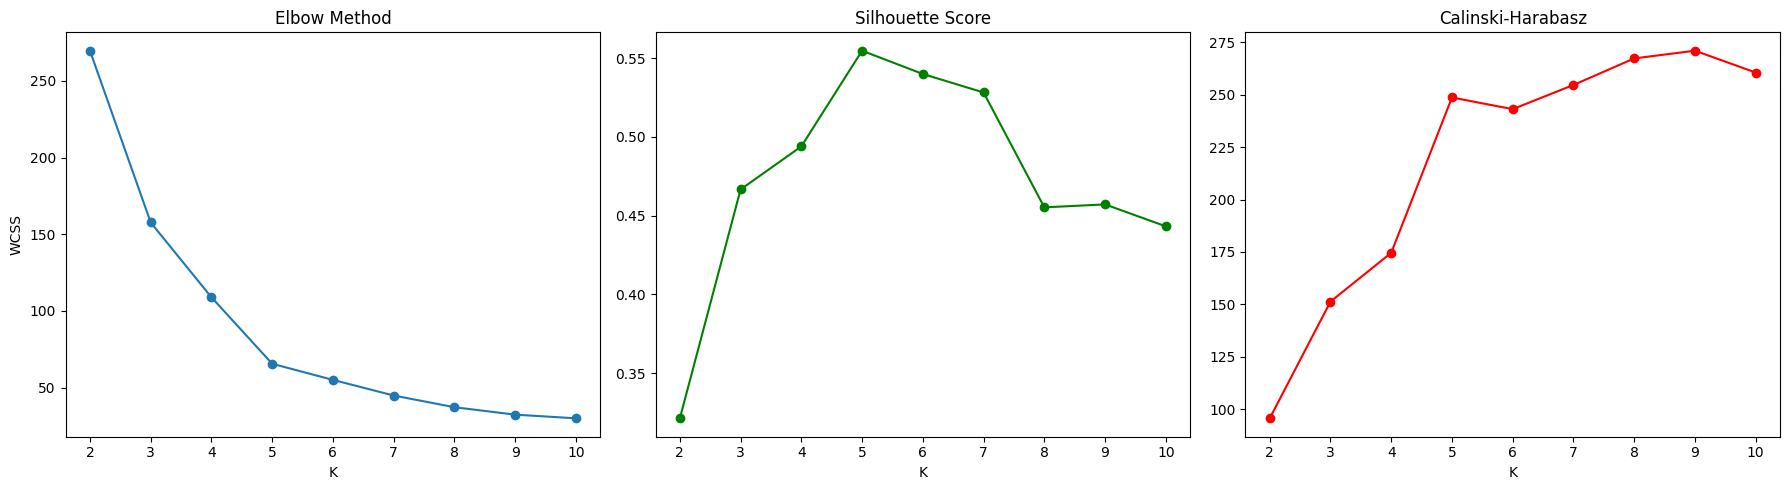

In [93]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

#ELBOW METHOD
axes[0].plot(k_range, inertia_values, marker='o')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K")
axes[0].set_ylabel("WCSS")

#SILHOUETTE METHOD
axes[1].plot(k_range, silhouette_scores, marker='o', color='green')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")

#CALINSKI-HARABASZ METHOD
axes[2].plot(k_range, ch_scores, marker='o', color='red')
axes[2].set_title("Calinski-Harabasz")
axes[2].set_xlabel("K")

plt.tight_layout()
plt.show()


##FINAL MODEL

In [95]:
best_k = 5
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)




##VISUALIZE CLUSTERS

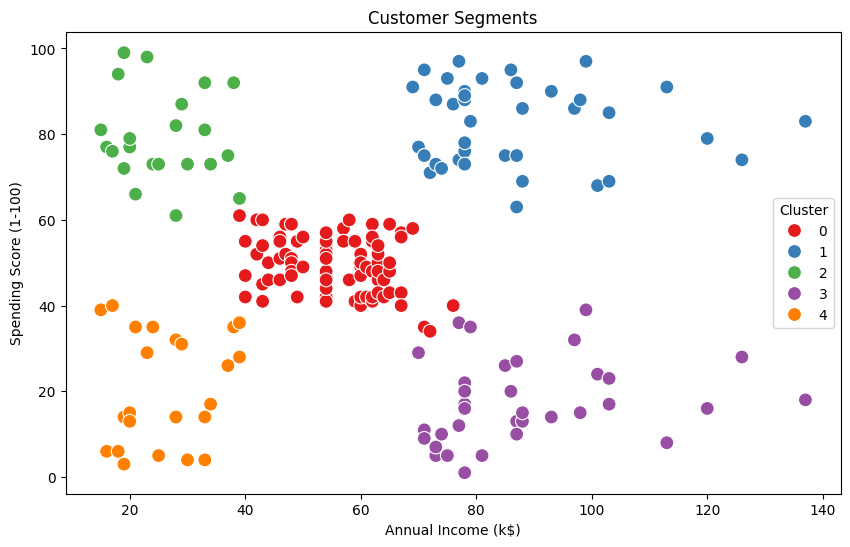

In [96]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title("Customer Segments")
plt.show()

##CLUSTER SUMMARY

In [97]:
summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(summary)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


##BUSINESS INTERPRETATION
"""
Cluster 0 = Low income / low spending

Cluster 1 = High income / high spending

Cluster 2 = High income / low spending

Cluster 3 = Low income / high spending

Cluster 4 = Average customers
"""

In [100]:
for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Score={score:.3f}")


K=2, Score=0.397
K=3, Score=0.467
K=4, Score=0.494
K=5, Score=0.555
K=6, Score=0.514
K=7, Score=0.502
K=8, Score=0.455
K=9, Score=0.457
K=10, Score=0.445
